# InstructSAM: A Training-Free Framework for Instruction-Oriented Remote Sensing Object Recognition
<a href="https://modelscope.cn/notebook/share/github/VoyagerXvoyagerx/InstructSAM/blob/main/demo/inference_demo.ipynb" target="_blank">
 <img src="https://img.shields.io/badge/%20-Open%20in%20ModelScope%20Notebook-624aff?logo=modelscope&labelColor=555"/>
</a>
<a target="_blank" href="https://colab.research.google.com/drive/1Ya7h04ZRPuHv3b934VoGJRMI0QpkH2oo?usp=sharing">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


### Installation

In [1]:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys
%pip install opencv-python matplotlib open-clip-torch pycocotools pulp tabulate lvis sentencepiece scikit-learn
%pip install 'git+https://github.com/facebookresearch/sam2.git'

import os
if not os.path.exists('InstructSAM'):
    !git clone https://github.com/VoyagerXvoyagerx/InstructSAM.git
%cd InstructSAM/

# Install InstructSAM from local clone (--no-deps since we installed deps separately)
%pip install -e . --no-deps
%pip install qwen-vl-utils==0.0.8 2>/dev/null || echo "qwen-vl-utils not available (OK for API-based inference)"

# Download checkpoints from ModelScope
from modelscope.hub.snapshot_download import snapshot_download
import shutil
os.makedirs('./checkpoints', exist_ok=True)

# SAM2 checkpoint
if not os.path.exists('./checkpoints/sam2_hiera_base_plus.pt'):
    print("Downloading SAM2 checkpoint from ModelScope...")
    sam2_dir = snapshot_download(
        'OpenGeoScope/sam2_hiera_base_plus',
        local_dir='./checkpoints/sam2_dl',
        allow_patterns=['sam2_hiera_base_plus.pt']
    )
    shutil.move(os.path.join(sam2_dir, 'sam2_hiera_base_plus.pt'), './checkpoints/sam2_hiera_base_plus.pt')
    shutil.rmtree('./checkpoints/sam2_dl', ignore_errors=True)

# GeoRSCLIP checkpoint
if not os.path.exists('./checkpoints/RS5M_ViT-L-14.pt'):
    print("Downloading GeoRSCLIP checkpoint from ModelScope...")
    georsclip_dir = snapshot_download(
        'OpenGeoScope/GeoRSCLIP',
        local_dir='./checkpoints/georsclip_dl',
        allow_patterns=['RS5M_ViT-L-14.pt']
    )
    shutil.move(os.path.join(georsclip_dir, 'RS5M_ViT-L-14.pt'), './checkpoints/RS5M_ViT-L-14.pt')
    shutil.rmtree('./checkpoints/georsclip_dl', ignore_errors=True)

%ls ./checkpoints

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA is available: True


Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple



[notice] A new release of pip is available: 23.3.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
  Cloning https://github.com/facebookresearch/sam2.git to /tmp/pip-req-build-xzqyjl95
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam2.git /tmp/pip-req-build-xzqyjl95


...


[notice] A new release of pip is available: 23.3.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple


Note: you may need to restart the kernel to use updated packages.


config.yaml  RS5M_ViT-L-14.pt  sam2_hiera_base_plus.pt


### Init Pretrained Models

In [ ]:
import sys, types, base64, mimetypes, openai

# Ensure qwen_vl_utils is importable (instruct_sam.counting imports it at module level)
try:
    import qwen_vl_utils
except ImportError:
    _mock = types.ModuleType('qwen_vl_utils')
    _mock.process_vision_info = None
    sys.modules['qwen_vl_utils'] = _mock

from instruct_sam.instruct_sam import InstructSAM
from instruct_sam.matching import init_clip_model
from instruct_sam.visualize import visualize_prediction
import instruct_sam.counting as _counting
import instruct_sam.instruct_sam as _isam

# # Example api key, for this demo only.
# openai.api_key = 'sk-RWrbcDyifkghniRiE1FeC79a9c1244F19063AaC7266c3dA2'
# openai.base_url = "https://api.gpt.ge/v1/"
# model_name = 'qwen3.5-27b'

# It is recommended to use modelscope API inference (2000 free calls/day) to test.
openai.api_key = 'your modelscope token'
openai.base_url = "https://api-inference.modelscope.cn/v1"
model_name = 'Qwen/qwen3.5-27b'

# Monkey-patch encode_image_as_base64: detect MIME type from file extension
def _encode_image_as_base64(image_path):
    mime_type, _ = mimetypes.guess_type(image_path)
    if mime_type is None:
        mime_type = "image/png"
    with open(image_path, "rb") as img_file:
        return f"data:{mime_type};base64,{base64.b64encode(img_file.read()).decode('utf-8')}"

# Monkey-patch predict: add response_format fallback for APIs that don't support json_object
def _predict(text_prompt, encoded_image, top_p=1, temperature=1, model="gpt-4o-2024-11-20", json_output=False):
    messages = [{"role": "user", "content": [
        {"type": "text", "text": text_prompt},
        {"type": "image_url", "image_url": {"url": encoded_image}}
    ]}]
    if json_output:
        try:
            return openai.chat.completions.create(
                model=model, messages=messages, top_p=top_p, temperature=temperature,
                response_format={"type": "json_object"})
        except Exception:
            pass
    return openai.chat.completions.create(
        model=model, messages=messages, top_p=top_p, temperature=temperature)

# Patch both the counting module and the instruct_sam module (which imported predict at top level)
_counting.encode_image_as_base64 = _encode_image_as_base64
_counting.predict = _predict
_isam.encode_image_as_base64 = _encode_image_as_base64
_isam.predict = _predict

print(f"API configured: {openai.base_url} | model: {model_name}")

API configured: https://api.gpt.ge/v1/ | model: qwen3.5-27b


In [3]:
device = torch.device("cuda")
# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
# turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
if torch.cuda.get_device_properties(0).major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

clip_model = 'georsclip'
clip_checkpoint = './checkpoints/RS5M_ViT-L-14.pt'
model, tokenizer, preprocess = init_clip_model(clip_model, device, clip_checkpoint)

In [4]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

sam2_checkpoint = './checkpoints/sam2_hiera_base_plus.pt'
model_cfg = "sam2_hiera_b+"
sam2 = build_sam2(model_cfg, sam2_checkpoint,
                  device=device, apply_postprocessing=False)
mask_generator = SAM2AutomaticMaskGenerator(sam2, pred_iou_thresh=0.75, stability_score_thresh=0.75,
                       points_per_side=24, crop_n_layers=1, box_nms_thresh=0.5)

In [5]:
instruct_sam = InstructSAM()

### Inference Examples

#### Satellite Image

In [6]:
image_path = './datasets/dior/JPEGImages-trainval/09938.jpg'
instruct_sam.set_image(image_path)

prompt = """
{
    "Persona": "You are an advanced AI model capable of understanding and analyzing remote sensing images.",
    "Task": "Given an input satellite imagery, count the number of all the visible remote sensing objects or scenes. Provide the results in JSON format where the keys are the category names and the values are the corresponding counts.",
    "Instructions": [
        "The spatial resolution of the imagery in the dataset ranges from 0.3 m to 30 m.",
        "If the resolution is too limited or the scene is too dense to accurately count certain objects, exclude those objects from the results.",
        "Only count objects that are clearly visible in the imagery."],
    "Output format": "{ "category1": count1, "category2": count2, ... }",
    "Answer": [
        "Ensure the category names are in singular form",
        "Provide the counts as integers."]
}
"""
instruct_sam.count_objects(prompt, gpt_model=model_name, json_output=True)
print(f'response: \n{instruct_sam.response}')

response: 
{
    "car": 21,
    "building": 6,
    "tree": 48,
    "tennis-court": 2,
    "basketball-court": 2
}


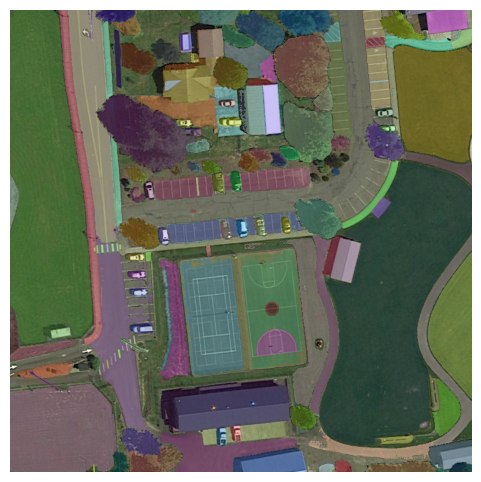

147

In [7]:
instruct_sam.segment_anything(mask_generator, max_masks=200)
instruct_sam.show_masks()
instruct_sam.num_masks

Visualization of similarity scores. The label assigned to each region (mask) proposal represents the category with the highest similarity to that proposal.
> Note: The assigned label here may differ from the final matching results, as the matching process is constrained by object counts.

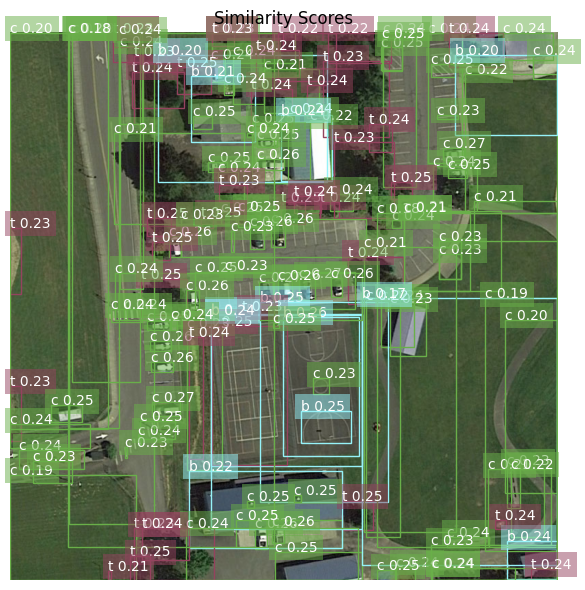

In [8]:
instruct_sam.calculate_pred_text_features(model, tokenizer, use_vocab=False)
instruct_sam.match_boxes_and_labels(model, preprocess, show_similarities=True);

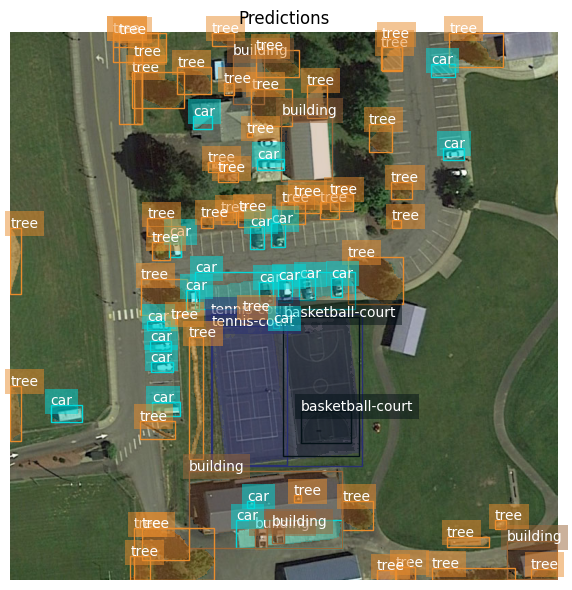

In [9]:
visualize_prediction(instruct_sam.img_array, instruct_sam.boxes_final,
                     instruct_sam.labels_final, instruct_sam.segmentations_final,
                     dpi=100)
# save image
box_final = instruct_sam.boxes_final
label_final = instruct_sam.labels_final

#### Natural Image

Equipped with generic CLIP model, InstructSAM can recognize objects in natural images.

In [10]:
from modelscope.hub.snapshot_download import snapshot_download
import os, shutil

if not os.path.exists('./checkpoints/open_clip_pytorch_model.bin'):
    print("Downloading DFN2B-CLIP checkpoint from ModelScope...")
    dfn2b_dir = snapshot_download(
        'apple/DFN2B-CLIP-ViT-L-14-39B',
        local_dir='./checkpoints/dfn2b_dl',
        allow_patterns=['open_clip_pytorch_model.bin']
    )
    shutil.move(os.path.join(dfn2b_dir, 'open_clip_pytorch_model.bin'),
                 './checkpoints/open_clip_pytorch_model.bin')
    shutil.rmtree('./checkpoints/dfn2b_dl', ignore_errors=True)

clip_model = 'dfn2b'
clip_checkpoint = './checkpoints/open_clip_pytorch_model.bin'

model, tokenizer, preprocess = init_clip_model(clip_model, device, clip_checkpoint)

2026-07-30 13:21:48,719 | INFO    | modelscope_hub.download | Downloading 1 files from apple/DFN2B-CLIP-ViT-L-14-39B@master


Downloading:   0%|          | 0/1 [00:00<?, ?file/s]

/usr/local/lib/python3.12/site-packages/modelscope_hub/_download.py:482: FutureWarning: Environment variable 'INTRA_CLOUD_ACCELERATION_REGION' is deprecated, use 'MODELSCOPE_DOWNLOAD_INTRA_CLOUD_REGION' instead.
  self._download_with_resume(


open_clip_pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

In [11]:
image_path = './demo/chip.jpg'
instruct_sam.set_image(image_path)

prompt = """
{
    "Persona": "You are an advanced AI model capable of understanding and analyzing images."
    "Task": "Given an input imagery, count the number of visible objects that belong to the parent category **electronic componets**. Provide the results in JSON format where the keys are the names of the subcategories and the values are the corresponding counts.",
    "Output format": "{ "subcategory1": count1, "subcategory2": count2, ... }",
    "Answer": ["Ensure the category names are in singular form",
                "Provide the counts as integers."]
}
"""
instruct_sam.count_objects(prompt, gpt_model=model_name, json_output=True)
print(f'response: \n{instruct_sam.response}')

response: 
{
    "capacitor": 16,
    "resistor": 12,
    "inductor": 3,
    "transistor": 4,
    "integrated circuit": 1
}


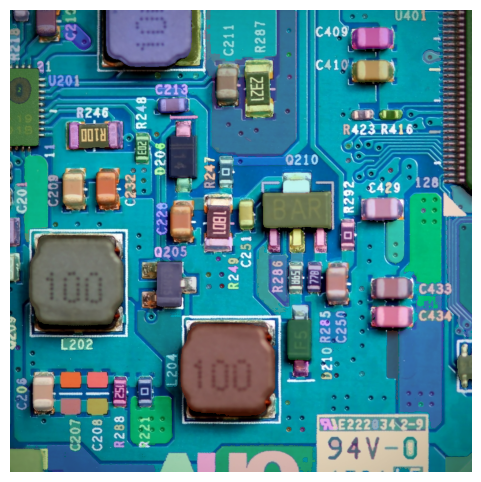

200

In [12]:
instruct_sam.segment_anything(mask_generator, max_masks=200)
instruct_sam.show_masks()
instruct_sam.num_masks

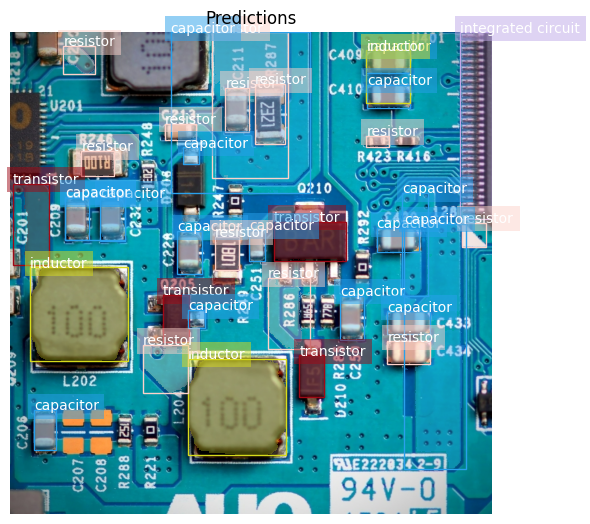

In [13]:
instruct_sam.calculate_pred_text_features(model, tokenizer, use_vocab=False);
instruct_sam.match_boxes_and_labels(model, preprocess, show_similarities=False);

visualize_prediction(instruct_sam.img_array, instruct_sam.boxes_final,
                     instruct_sam.labels_final, instruct_sam.segmentations_final,
                     dpi=100)